#Investigating the Ukrainian Refugee Crisis
###by: Luke Volpe   
[Link to project site here](https://lvolpe03.github.io/)

##Project Goals
The goal of this project is to investigate patterns in the movement of Ukrainian refugees as a result of the February 2022 Russian invasion. I will also be analyzing the relationships between refugee flows and host country indicators, as well as measures of the refugees' economic integration.

##Collaboration Plan (N/A)
As a Master's student, I am working alone and will not need a specialized plan.

##Project Dataset 1

The first dataset that I will use comes from the [Refugee Data Finder](https://www.unhcr.org/refugee-statistics/download) at the United Nations High Commissioner for Refugees (UNHCR), the leading international institution on migration data. This database contains yearly population counts of refugee, asylum-seeker, and internally displaced persons, as well as their countries of origin and asylum. I am interested in this dataset because it is the most basic form of tracking refugee migration destinations. I will use it to answer questions like "Which countries have received the largest volumes of refugees?" or "Have refugee populations increased, decreased, or stabilized over the course of the war?"

In [463]:
%cd /content/drive/MyDrive/CMPS 6160 (Data Sci)/Proj Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/content/drive/MyDrive/CMPS 6160 (Data Sci)/Proj Data


In [464]:
df_RefCounts_Orig = pd.read_csv('UKR Refugee Counts.csv')
df_RefCounts_Orig

,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Refugees,Asylum-seekers,IDPs,Other people in need of international protection
0,2022,Albania,Ukraine,ALB,UKR,2542,5,0,0
1,2023,Albania,Ukraine,ALB,UKR,4959,0,0,0
2,2024,Albania,Ukraine,ALB,UKR,9250,0,0,0
3,2022,Egypt,Ukraine,EGY,UKR,0,5,0,0
4,2023,Egypt,Ukraine,EGY,UKR,0,9,0,0
...,...,...,...,...,...,...,...,...,...
236,2023,Uruguay,Ukraine,URY,UKR,18,0,0,0
237,2024,Uruguay,Ukraine,URY,UKR,18,5,0,0
238,2022,United States of America,Ukraine,USA,UKR,3063,12369,0,0
239,2023,United States of America,Ukraine,USA,UKR,3299,17773,0,0


Because we know we are dealing only with refugee populations originating from Ukraine, we can drop the variables about country of origin. I will also drop the "Other people in need of international protection" column because it contains no relevant data to my study, and it is filled only with zeros. I will also rename some of the asylum countries for convenience sake. Lastly, I will create a joint measure of refugees and asylum seekers. Since the distinction between the two classifications [is primarily legal](https://www.rescue.org/article/migrants-asylum-seekers-refugees-and-immigrants-whats-difference), if we want to know generally about all the people the war has displaced, we should use a combined count.

In [465]:
# Dropping variables:
df_RefCounts = df_RefCounts_Orig.drop(columns=['Country of Origin', 'Country of Origin ISO', 'Other people in need of international protection'])

# Renaming countries:
df_RefCounts["Country of Asylum"] = df_RefCounts["Country of Asylum"].replace({
    'Bolivia (Plurinational State of)': 'Bolivia',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United States of America': 'United States',
    'Rep. of Korea': 'South Korea',
    'Rep. of Moldova': 'Moldova',
    'Netherlands (Kingdom of the)': 'Netherlands',
    'Russian Federation': 'Russia',
    'Serbia and Kosovo: S/RES/1244 (1999)': 'Serbia',
    'United Rep. of Tanzania': 'Tanzania'
})
#Joint measure
df_RefCounts['Ref_Asylum'] = df_RefCounts['Refugees'] + df_RefCounts['Asylum-seekers']
df_RefCounts

,Year,Country of Asylum,Country of Asylum ISO,Refugees,Asylum-seekers,IDPs,Ref_Asylum
0,2022,Albania,ALB,2542,5,0,2547
1,2023,Albania,ALB,4959,0,0,4959
2,2024,Albania,ALB,9250,0,0,9250
3,2022,Egypt,EGY,0,5,0,5
4,2023,Egypt,EGY,0,9,0,9
...,...,...,...,...,...,...,...
236,2023,Uruguay,URY,18,0,0,18
237,2024,Uruguay,URY,18,5,0,23
238,2022,United States,USA,3063,12369,0,15432
239,2023,United States,USA,3299,17773,0,21072


The data above is in a basic tidy format. While proper database management would create a system of relational tables, this will suffice for our purposes right now. Next, we must check the dtypes. We see that they are already correctly coded, with our categorical variables as objects and our quantitative variables as int64:

In [466]:
df_RefCounts.dtypes

,0
Year,int64
Country of Asylum,object
Country of Asylum ISO,object
Refugees,int64
Asylum-seekers,int64
IDPs,int64
Ref_Asylum,int64


##Project Dataset 2

My next dataset comes from the World Bank's [World Development Indicators](https://databank.worldbank.org/source/world-development-indicators) (WDI). This database offers more than 1500 different variables at the national level and covers broad topics like the environment, education, and inequality, to name just a few. I used their built-in database query interface to select variables focusing on my outcomes of interest, primarily those related to the economy, education, and demography. I also narrowed the database down to the three years of interest (2022-2024). My plan is to conduct a left join on country and year using the `df_RefCounts` as df1, so it only keeps country/year combinations that have recorded Ukrainian refugee data.   

With this data, I hope to build contextual profiles for each country of asylum. It will help me answer questions like, "How much of the refugee population is absorbed by countries with high vs. low levels of development?", and "Do larger inflows of refugees correlate with better or worse labor market outcomes?"   

Additionally, once I bring in demographic data for the refugees themselves, I can compare indicators like educational attainment between the host country and refugee populations. Anti-immigration narratives often claim that migrants are an additional weight on the economy, but information like this can shed light on the true patterns.



In [467]:
df_WDI_Orig = pd.read_csv('WDI 1.csv')
df_WDI_Orig

,Country Name,Country Code,Series Name,Series Code,2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,Afghanistan,AFG,"Adjusted net enrollment rate, primary (% of pr...",SE.PRM.TENR,..,..,..
1,Afghanistan,AFG,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,..,..,..
2,Afghanistan,AFG,Coverage of social safety net programs (% of p...,per_sa_allsa.cov_pop_tot,..,..,..
3,Afghanistan,AFG,"Educational attainment, at least Bachelor's or...",SE.TER.CUAT.BA.ZS,3.98425006866455,..,..
4,Afghanistan,AFG,"Educational attainment, at least completed pri...",SE.PRM.CUAT.ZS,21.0254802703857,..,..
...,...,...,...,...,...,...,...
10416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10419,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN


Upon loading in this table, we see we must reshape it from wide to long format. First, let's melt the years data into one column, clean up the syntax of the `Year` column, and then pivot the table so each indicator is its own column.

In [468]:
# Melt
df_WDI_melt = df_WDI_Orig.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    var_name='Year',
    value_name='Value'
)
# Replace year values to clean syntax and convert to int64s
df_WDI_melt['Year'] = df_WDI_melt['Year'].replace({
    '2022 [YR2022]': 2022,
    '2023 [YR2023]': 2023,
    '2024 [YR2024]': 2024
})

/tmp/ipython-input-1904443984.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_WDI_melt['Year'] = df_WDI_melt['Year'].replace({


In [469]:
# Before pivoting must drop the footnote observations at the end.
display(df_WDI_melt.tail(6))
df_WDI_melt = df_WDI_melt.iloc[:31258]

,Country Name,Country Code,Series Name,Series Code,Year,Value
31257,Zimbabwe,ZWE,"Unemployment, male (% of male labor force) (na...",SL.UEM.TOTL.MA.NE.ZS,2024,..
31258,NaN,NaN,NaN,NaN,2024,NaN
31259,NaN,NaN,NaN,NaN,2024,NaN
31260,NaN,NaN,NaN,NaN,2024,NaN
31261,Data from database: World Development Indicators,NaN,NaN,NaN,2024,NaN
31262,Last Updated: 10/07/2025,NaN,NaN,NaN,2024,NaN


I was still getting a Duplicate Index Entries error when pivoting, so let's search for and drop duplicates:

In [470]:
dupes = df_WDI_melt[df_WDI_melt.duplicated(
    subset=['Country Name', 'Country Code', 'Year', 'Series Name'],
    keep=False
)]
print(dupes)
df_WDI_melt = df_WDI_melt.drop(index=dupes.index)

      Country Name Country Code Series Name Series Code  Year Value
10416          NaN          NaN         NaN         NaN  2022   NaN
10417          NaN          NaN         NaN         NaN  2022   NaN
10418          NaN          NaN         NaN         NaN  2022   NaN
20837          NaN          NaN         NaN         NaN  2023   NaN
20838          NaN          NaN         NaN         NaN  2023   NaN
20839          NaN          NaN         NaN         NaN  2023   NaN


In [471]:
# Now pivot
df_WDI_pivot = df_WDI_melt.pivot(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Name',
    values='Value'
).reset_index()
# Drop the column labeled NaN
df_WDI_pivot.drop(columns=[np.nan], inplace=True)
# Fill blank values with NaN instead of ".."
df_WDI_pivot.replace('..', np.nan, inplace=True)
df_WDI_pivot

/tmp/ipython-input-1604900388.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_WDI_pivot.replace('..', np.nan, inplace=True)


Series Name,Country Name,Country Code,Year,"Adjusted net enrollment rate, primary (% of primary school age children)",Adjusted net national income per capita (current US$),Coverage of social safety net programs (% of population),"Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative)","Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative)","Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)",GDP growth (annual %),...,"School enrollment, secondary (% net)","School enrollment, tertiary (% gross)",Unemployment with advanced education (% of total labor force with advanced education),Unemployment with basic education (% of total labor force with basic education),"Unemployment, female (% of female labor force) (modeled ILO estimate)","Unemployment, female (% of female labor force) (national estimate)","Unemployment, male (% of male labor force) (modeled ILO estimate)","Unemployment, male (% of male labor force) (national estimate)","Unemployment, total (% of total labor force) (modeled ILO estimate)","Unemployment, total (% of total labor force) (national estimate)"
0,Afghanistan,AFG,2022,NaN,NaN,NaN,3.98425006866455,21.0254802703857,12.5973300933838,-6.24017199240269,...,NaN,NaN,NaN,NaN,26.742,NaN,13.168,NaN,14.1,NaN
1,Afghanistan,AFG,2023,NaN,NaN,NaN,NaN,NaN,NaN,2.26694373649188,...,NaN,NaN,NaN,NaN,26.57,NaN,13.066,NaN,13.991,NaN
2,Afghanistan,AFG,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,25.636,NaN,12.394,NaN,13.295,NaN
3,Albania,ALB,2022,NaN,NaN,NaN,19.8346436163563,97.8531397166699,53.2684854264147,4.82669611912765,...,NaN,62.647921513098,10.228,9.437,10.405,11.235,9.917,10.398,10.137,10.785
4,Albania,ALB,2023,NaN,NaN,NaN,17.5100002288818,99.2799987792969,53.9700012207031,3.93661689192599,...,NaN,64.7293520237257,8.947,9.694,10.376,10.958,9.888,10.421,10.108,10.669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,Zambia,ZMB,2023,NaN,NaN,NaN,2.80119454477244,NaN,33.5884544067257,5.36794285493059,...,NaN,NaN,9.702,3.688,6.207,6.037,5.646,5.71,5.905,5.861
651,Zambia,ZMB,2024,NaN,NaN,NaN,NaN,NaN,NaN,4.0431482994443,...,NaN,NaN,NaN,NaN,6.25,NaN,5.713,NaN,5.961,NaN
652,Zimbabwe,ZWE,2022,NaN,NaN,NaN,0.913877996562985,NaN,NaN,6.1391761744749,...,NaN,NaN,5.945,8.878,10.562,10.461,9.615,9.554,10.087,10.001
653,Zimbabwe,ZWE,2023,NaN,NaN,NaN,1.13487348253901,NaN,NaN,5.33677037339527,...,NaN,NaN,5.933,8.493,8.824,9.46,8.694,9.126,8.759,9.29


Shape looks good and footnotes are gone. Now we can check our dtypes for the WDI dataset, but it doesn't look good. All of our variables besides `Country Name` and `Country Code` should be numeric:

In [472]:
df_WDI_pivot.dtypes

,0
Series Name,
Country Name,object
Country Code,object
Year,int64
"Adjusted net enrollment rate, primary (% of primary school age children)",float64
Adjusted net national income per capita (current US$),float64
Coverage of social safety net programs (% of population),object
"Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative)",object
"Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative)",object
"Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)",object


In [473]:
df_WDI_pivot = df_WDI_pivot.apply(pd.to_numeric, errors='ignore')
df_WDI_pivot.dtypes
#Much better!

/tmp/ipython-input-2617470744.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_WDI_pivot = df_WDI_pivot.apply(pd.to_numeric, errors='ignore')


,0
Series Name,
Country Name,object
Country Code,object
Year,int64
"Adjusted net enrollment rate, primary (% of primary school age children)",float64
Adjusted net national income per capita (current US$),float64
Coverage of social safety net programs (% of population),float64
"Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative)",float64
"Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative)",float64
"Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)",float64


Due to variation in data availability and measurement, it is common for some World Development Indicators to contain no data. Here, we'll drop any variables that contain no information for any of our country-year observations. We will also recode the burdensome variable names exported from the WDIs.

In [474]:
#Drop columns that have NaN for all values
df_WDI_pivot.dropna(axis=1, how='all', inplace=True)

#Rename using dictionary
rename_dict = {
    'Country Name': 'Country Name',
    'Country Code': 'ISO',
    'Year': 'Year',
    'Coverage of social safety net programs (% of population)': 'SocialNet_Cov',
    "Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative)": 'Edu_Bach25p',
    'Educational attainment, at least completed primary, population 25+ years, total (%) (cumulative)': 'Edu_Prim25p',
    'Educational attainment, at least completed upper secondary, population 25+, total (%) (cumulative)': 'Edu_UpSec25p',
    'GDP growth (annual %)': 'GDP_Growth',
    'GDP per capita (current US$)': 'GDP_pc',
    'GDP per capita growth (annual %)': 'GDP_pc_Growth',
    'GNI per capita growth (annual %)': 'GNI_pc_Growth',
    'GNI per capita, Atlas method (current US$)': 'GNI_pc',
    'Gini index': 'Gini',
    'Government Effectiveness: Percentile Rank': 'GovEffect_rank',
    'Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)': 'LFPR_15_24_ILO',
    'Labor force participation rate for ages 15-24, total (%) (national estimate)': 'LFPR_15_24_Nat',
    'Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)': 'LFPR_15p_ILO',
    'Labor force participation rate, total (% of total population ages 15+) (national estimate)': 'LFPR_15p_Nat',
    'Labor force participation rate, total (% of total population ages 15-64) (modeled ILO estimate)': 'LFPR_15_64_ILO',
    'Labor force with advanced education (% of total working-age population with advanced education)': 'LF_AdvEdu',
    'Labor force with basic education (% of total working-age population with basic education)': 'LF_BasicEdu',
    'Labor force with intermediate education (% of total working-age population with intermediate education)': 'LF_IntEdu',
    'Labor force, female (% of total labor force)': 'LF_Fem',
    'Net official flows from UN agencies, UNHCR (current US$)': 'Net_UNHCR',
    'Political Stability and Absence of Violence/Terrorism: Percentile Rank': 'Pol_Stab_rank',
    'Population ages 15-64 (% of total population)': 'Pop_15_64_pct',
    'Population ages 15-64, female': 'Pop_15_64_Fem',
    'Population ages 15-64, male': 'Pop_15_64_Male',
    'Population ages 15-64, total': 'Pop_15_64_Tot',
    'Population growth (annual %)': 'Pop_Growth',
    'Population, female (% of total population)': 'Pop_Fem_pct',
    'Population, male (% of total population)': 'Pop_Male_pct',
    'Poverty headcount ratio at national poverty lines (% of population)': 'Poverty_pct',
    'Prevalence of moderate or severe food insecurity in the population (%)': 'FoodInsec_pct',
    'Primary completion rate, total (% of relevant age group)': 'PrimComp_pct',
    'Rule of Law: Percentile Rank': 'RuleLaw_rank',
    'School enrollment, primary (% gross)': 'Enroll_Prim',
    'School enrollment, secondary (% gross)': 'Enroll_Sec',
    'School enrollment, tertiary (% gross)': 'Enroll_Tert',
    'Unemployment with advanced education (% of total labor force with advanced education)': 'Unemp_AdvEdu',
    'Unemployment with basic education (% of total labor force with basic education)': 'Unemp_BasicEdu',
    'Unemployment, female (% of female labor force) (modeled ILO estimate)': 'Unemp_Fem_ILO',
    'Unemployment, female (% of female labor force) (national estimate)': 'Unemp_Fem_Nat',
    'Unemployment, male (% of male labor force) (modeled ILO estimate)': 'Unemp_Male_ILO',
    'Unemployment, male (% of male labor force) (national estimate)': 'Unemp_Male_Nat',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)': 'Unemp_Tot_ILO',
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemp_Tot_Nat'
}
df_WDI_pivot = df_WDI_pivot.rename(columns=rename_dict)
df_WDI_pivot

Series Name,Country Name,ISO,Year,SocialNet_Cov,Edu_Bach25p,Edu_Prim25p,Edu_UpSec25p,GDP_Growth,GDP_pc,GDP_pc_Growth,...,Enroll_Sec,Enroll_Tert,Unemp_AdvEdu,Unemp_BasicEdu,Unemp_Fem_ILO,Unemp_Fem_Nat,Unemp_Male_ILO,Unemp_Male_Nat,Unemp_Tot_ILO,Unemp_Tot_Nat
0,Afghanistan,AFG,2022,NaN,3.984250,21.025480,12.597330,-6.240172,357.261153,-7.576669,...,NaN,NaN,NaN,NaN,26.742,NaN,13.168,NaN,14.100,NaN
1,Afghanistan,AFG,2023,NaN,NaN,NaN,NaN,2.266944,413.757895,0.106093,...,NaN,NaN,NaN,NaN,26.570,NaN,13.066,NaN,13.991,NaN
2,Afghanistan,AFG,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,25.636,NaN,12.394,NaN,13.295,NaN
3,Albania,ALB,2022,NaN,19.834644,97.853140,53.268485,4.826696,6846.426694,6.108948,...,97.322471,62.647922,10.228,9.437,10.405,11.235,9.917,10.398,10.137,10.785
4,Albania,ALB,2023,NaN,17.510000,99.279999,53.970001,3.936617,8575.171346,5.137124,...,96.136877,64.729352,8.947,9.694,10.376,10.958,9.888,10.421,10.108,10.669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,Zambia,ZMB,2023,NaN,2.801195,NaN,33.588454,5.367943,1330.727806,2.464640,...,NaN,NaN,9.702,3.688,6.207,6.037,5.646,5.710,5.905,5.861
651,Zambia,ZMB,2024,NaN,NaN,NaN,NaN,4.043148,1235.084665,1.158387,...,56.788929,NaN,NaN,NaN,6.250,NaN,5.713,NaN,5.961,NaN
652,Zimbabwe,ZWE,2022,NaN,0.913878,NaN,NaN,6.139176,2040.546587,4.343582,...,NaN,NaN,5.945,8.878,10.562,10.461,9.615,9.554,10.087,10.001
653,Zimbabwe,ZWE,2023,NaN,1.134873,NaN,NaN,5.336770,2156.034093,3.584903,...,NaN,NaN,5.933,8.493,8.824,9.460,8.694,9.126,8.759,9.290


Now our World Bank indicators are ready for merging and further analysis.

##Initial Exploratory Data Analysis (EDA)

To begin our EDA, we will create a pie chart to answer the question, "What countries have the largest Ukrainian refugee populations today?" This is a simple yet helpful snapshot of how the refugees are distributed across host countries. Later analysis will tell us things like how these refugee stocks have fluctuated over the course of the war.

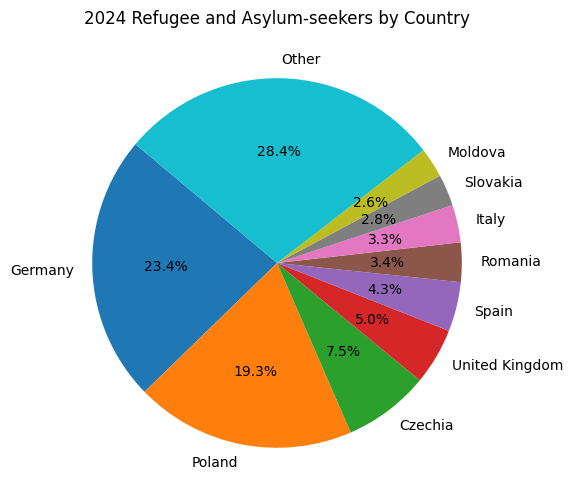

In [475]:
# Isolate latest year
RefCounts_2024 = df_RefCounts[df_RefCounts['Year']== 2024].copy()
RefCounts_2024 = RefCounts_2024.sort_values('Ref_Asylum', ascending=False)

# Build df of top n countries
top_n = 9
top_2024 = RefCounts_2024.head(top_n)

# Sum the rest of the counts into a one-observation df for "Other"
others_sum = RefCounts_2024['Ref_Asylum'].iloc[top_n:].sum()
df_other = pd.DataFrame({'Country of Asylum':['Other'],'Ref_Asylum':[others_sum]})

# Concatenate the two
df_piechart = pd.concat([top_2024, df_other], ignore_index=True)

# Now we actually make the chart
plt.figure(figsize=(6,6))
plt.pie(
    df_piechart['Ref_Asylum'],
    labels = df_piechart['Country of Asylum'],
    autopct = '%1.1f%%',
    startangle = 140
    )
plt.title('2024 Refugee and Asylum-seekers by Country')
plt.show()

As we can see, the top countries are all in Europe, and about 50% of all Ukrainian refugees today are located in only 3 countries: Germany, Poland, and Czechia. In fact, the top 9 countries host 71.6% of all refugees. Knowing this opens the door for a possible case-study into refugee integration efforts in the few countries that would have the greatest impact.

Another interesting graphic we can make to show the distribution is a histogram of our 82 host countries by their 2024 Ukrainian refugee/asylum-seeker populations:

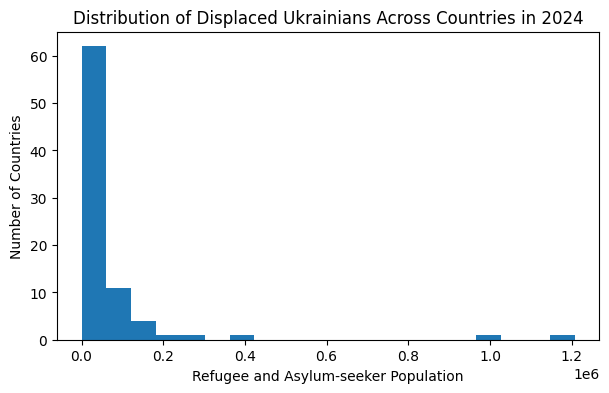

In [476]:
plt.figure(figsize=(7,4))
plt.hist(RefCounts_2024['Ref_Asylum'], bins=20)
plt.xlabel('Refugee and Asylum-seeker Population')
plt.ylabel('Number of Countries')
plt.title(f'Distribution of Displaced Ukrainians Across Countries in 2024')
plt.show()

We clearly see the data has a large right skew, representing how a few countries have large numbers of refugees. To correct for this, we can transform the data. Once done, this transformed data can help us better model the data with OLS regression, for example. Here, I've selected a log transformation because it will compress extreme values to a roughly symmetrical distribution (shown below) and still allow for easy coefficient interpretations in later regressions.

Skew (original): 5.109567696854691
Skew (log-transformed): -0.16770937897938587


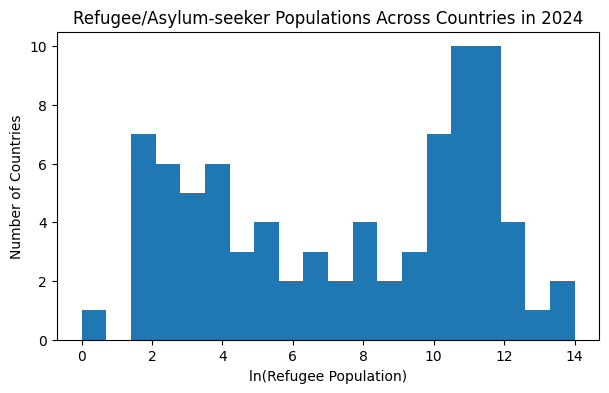

In [477]:
#Log-transform refugee counts into a more evenly distributed shape, creating a new column in the main RefCounts df.
x = df_RefCounts['Ref_Asylum']
df_RefCounts['ln_Ref_Asylum'] = np.log(x + 1) # Add 1 to account for zeros

#Now filter again to latest year
RefCounts_2024 = df_RefCounts[df_RefCounts['Year'] == 2024].copy()

#Calculate skew and check log-transformation is sufficiently symmetrical
from scipy.stats import skew
print("Skew (original):", skew(RefCounts_2024['Ref_Asylum']))
print("Skew (log-transformed):", skew(RefCounts_2024['ln_Ref_Asylum'])) #Should be near zero

plt.figure(figsize=(7,4))
plt.hist(RefCounts_2024['ln_Ref_Asylum'], bins=20)
plt.xlabel('ln(Refugee Population)')
plt.ylabel('Number of Countries')
plt.title(f'Refugee/Asylum-seeker Populations Across Countries in 2024')
plt.show()

##Looking Ahead

In the next phase of my project, I will merge my two datasets together to begin looking at the relationships between host country indicators and refugee flows. I also hope to incorporate more data describing the refugee populations themselves so I can compare them to host populations.

##Mount and Extract:

In [478]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [479]:
!jupyter nbconvert --to html "/content/drive/MyDrive/CMPS 6160 (Data Sci)/Milestone 1"

[NbConvertApp] Converting notebook /content/drive/MyDrive/CMPS 6160 (Data Sci)/Milestone 1 to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 535029 bytes to /content/drive/MyDrive/CMPS 6160 (Data Sci)/Milestone .html
